In [1]:
import sys
sys.path.append('../code')

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from network_utils import make_network, set_train_parameters, gaussian_tuning, StimSynapse, get_currents, IonotropicSynapse, get_parameter_names
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum

import prior_configurations as prior_config

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [2]:
def psr(p1_points, p2_points, step_size, num_dim=1):
    """Calculate proportion of similar responses (PSR)
    Parameters
    ----------
    p1_points: array-like
    
    p2_points: array-like
    
    step_size: float
    
    num_dim: int
    
    Returns
    -------
    overlap_value: float
        Approximately bounded on [0,1]
    """
    points = np.vstack([p1_points, p2_points]).T
    min_points = np.min(points, axis=1)
    overlap_value = np.sum(min_points * (step_size ** num_dim))
    return overlap_value

In [3]:
save_path1 = '/users/ntolley/data/ntolley/dendractor/memory_permutations'
config_list1 = [
    ('cuesomanmda_Esomaampa_Edendampa', prior_config.update_prior_dict_cuesomanmda_Esomaampa_Edendampa), # 4
    ('cuesomaampa_Esomaampa_Edendampa', prior_config.update_prior_dict_cuesomaampa_Esomaampa_Edendampa), # 5
    ('cuedendnmda_Esomaampa_Edendampa', prior_config.update_prior_dict_cuedendnmda_Esomaampa_Edendampa), # 10
    ('cuedendampa_Esomaampa_Edendampa', prior_config.update_prior_dict_cuedendampa_Esomaampa_Edendampa), # 11
    ]

save_path2 = '/users/ntolley/data/ntolley/dendractor/memory_permutations_receptor_dynamics'
config_list2 = [
    ('cuedendnmdafast_Esomaampa_Edendampa', prior_config.update_prior_dict_cuedendnmdafast_Esomaampa_Edendampa),
    ('cuedendampaslow_Esomaampa_Edendampa', prior_config.update_prior_dict_cuedendampaslow_Esomaampa_Edendampa),
    ('cuedendampa_Esomaampa_Edendampa_lowaxialres', prior_config.update_prior_dict_cuedendampa_Esomaampa_Edendampa_lowaxialres),
    ]

t_max = 1000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(8000 / downsample_factor)

In [4]:
def get_opt_data(data_path, num_flows=10):
    print(f'Loading data from: {data_path}')
    theta_list = list()
    error_list = list()

    for flow_idx in range(num_flows):
        print(f'Flow {flow_idx}')
        theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
        error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')

        theta_list.append(theta)
        error_list.append(error)


    error_sort = np.argsort(error)


    res_dict = {'theta_list': theta_list, 'error_list': error_list, 'error_sort': error_sort}

    return res_dict

In [6]:
num_flows = 9

res_dict = dict()
for name, _ in config_list1:
    data_path = f'{save_path1}/{name}'
    res_dict[name] = get_opt_data(data_path, num_flows=num_flows)

for name, _ in config_list2:
    data_path = f'{save_path2}/{name}'
    res_dict[name] = get_opt_data(data_path, num_flows=num_flows)

Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations/cuesomanmda_Esomaampa_Edendampa
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations/cuesomaampa_Esomaampa_Edendampa
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations/cuedendnmda_Esomaampa_Edendampa
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations/cuedendampa_Esomaampa_Edendampa
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations_receptor_dynamics/cuedendnmdafast_Esomaampa_Edendampa
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations_receptor_dynamics/cuedendampaslow_E

In [7]:
res_dict.keys()

dict_keys(['cuesomanmda_Esomaampa_Edendampa', 'cuesomaampa_Esomaampa_Edendampa', 'cuedendnmda_Esomaampa_Edendampa', 'cuedendampa_Esomaampa_Edendampa', 'cuedendnmdafast_Esomaampa_Edendampa', 'cuedendampaslow_Esomaampa_Edendampa', 'cuedendampa_Esomaampa_Edendampa_lowaxialres'])

In [26]:
color_dict = {
        'cuedendnmda_Esomaampa_Edendampa': 'C0',
        'cuedendnmdafast_Esomaampa_Edendampa': 'plum',

        'cuedendampa_Esomaampa_Edendampa': 'lightsteelblue',
        'cuedendampaslow_Esomaampa_Edendampa': 'mediumorchid',
        'cuedendampa_Esomaampa_Edendampa_lowaxialres': 'palevioletred',

        'cuesomanmda_Esomaampa_Edendampa': 'C3',
        'cuesomaampa_Esomaampa_Edendampa': 'darkorange'
}

legend_dict = {
        'cuedendnmda_Esomaampa_Edendampa': '$\\rm NMDA_{dend}$',
        'cuedendampa_Esomaampa_Edendampa': '$\\rm AMPA_{dend}$',
        'cuesomanmda_Esomaampa_Edendampa': '$\\rm NMDA_{soma}$',
        'cuesomaampa_Esomaampa_Edendampa': '$\\rm AMPA_{soma}$',

        'cuedendnmdafast_Esomaampa_Edendampa': '$\\rm NMDA_{dend}^{fast}$',
        'cuedendampaslow_Esomaampa_Edendampa': '$\\rm AMPA_{dend}^{slow}$',
        'cuedendampa_Esomaampa_Edendampa_lowaxialres': '$\\rm AMPA_{dend}^{lowres}$',
}

label_dict = {
        'E_Leak_gLeak': '$\\rm E_{soma} \\bar{g}_{leak}$',
        'E_dend_Leak_gLeak': '$\\rm E_{dend} \\bar{g}_{leak}$'
}



In [27]:
param_names = get_parameter_names()[0]

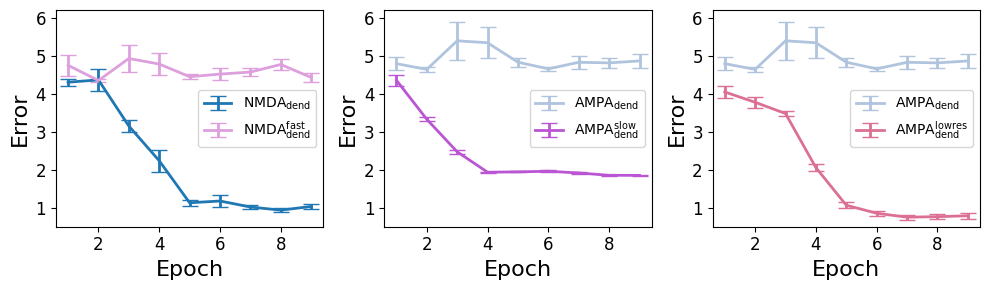

In [28]:
plot_groups = [['cuedendnmda_Esomaampa_Edendampa', 'cuedendnmdafast_Esomaampa_Edendampa'],
               ['cuedendampa_Esomaampa_Edendampa', 'cuedendampaslow_Esomaampa_Edendampa'],
               ['cuedendampa_Esomaampa_Edendampa', 'cuedendampa_Esomaampa_Edendampa_lowaxialres']]

# plot_param_names = ['E_Leak_gLeak', 'E_dend_Leak_gLeak']
# plot_param_names = ['E_Km_gKm', 'E_dend_Km_gKm']
plot_param_names = ['EE_ampa_gS', 'EE_dend_ampa_gS', 'EI_ampa_gS', 'IE_gaba_gS', 'IE_dend_gaba_gS', 'II_gaba_gS']


labelsize = 16
ticksize = 12
legendsize = 10
linewidth = 2
xticks = np.array(list(range(1,len(res_dict['cuedendnmda_Esomaampa_Edendampa']['error_list'])+1)))

bins = np.linspace(0, 1, 30)


plt.figure(figsize=(10,3))
for plot_idx, group in enumerate(plot_groups):
    theta_compare = list()
    for name in group:
        # Plot error bars
        plt.subplot(1,3,plot_idx+1)
        label = legend_dict[name]
        color = color_dict[name]
        error_avg = np.mean(np.array(res_dict[name]['error_list']), axis=1)
        error_std = np.std(np.array(res_dict[name]['error_list']), axis=1) / np.sqrt(100)
        plt.errorbar(x=xticks, y=error_avg, yerr=error_std, linewidth=linewidth, label=label, capsize=6, color=color)

        plt.xticks(fontsize=ticksize)
        plt.yticks(fontsize=ticksize)
        plt.legend(fontsize=legendsize, loc='center right')
        plt.ylabel('Error', fontsize=labelsize)
        plt.xlabel('Epoch', fontsize=labelsize)
        plt.ylim(0.5, 6.2)

        # Plot PCA trajectory
        

        # plt.title(f'{label_dict[param_name]} (log g)', fontsize=titlesize)


    # plt.xlim(0, 11)
plt.tight_layout()

figure_path = '/users/ntolley/data/ntolley/dendractor/memory_permutations/figures'
plt.savefig(f'{figure_path}/error_comparison_receptor_dynamics.svg')

ValueError: num must be an integer with 1 <= num <= 12, not 13

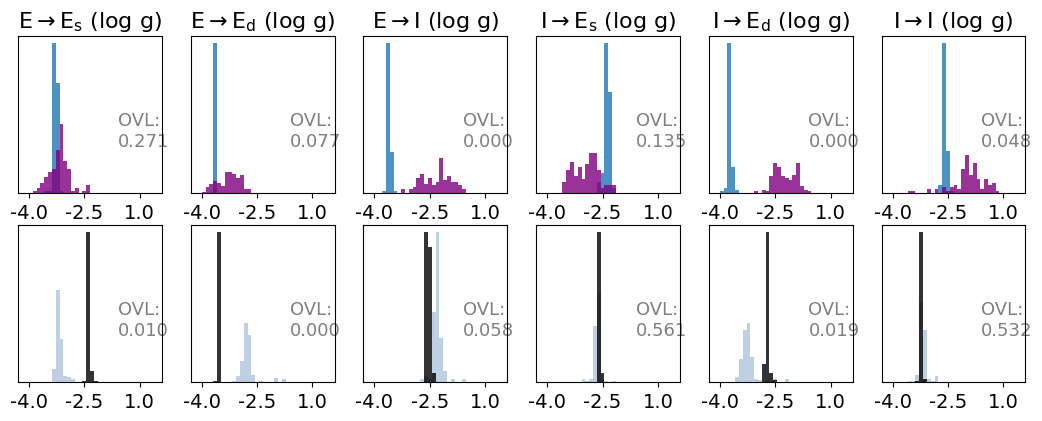

In [14]:
ticksize = 14
titlesize = 16
param_names = get_parameter_names()[0]

plot_groups = [['cuedendnmda_Esomaampa_Edendampa', 'cuedendnmdafast_Esomaampa_Edendampa'],
               ['cuedendampa_Esomaampa_Edendampa', 'cuedendampaslow_Esomaampa_Edendampa'],
               ['cuedendampa_Esomaampa_Edendampa', 'cuedendampa_Esomaampa_Edendampa_lowaxialres']]

plot_param_names = ['EE_ampa_gS', 'EE_dend_ampa_gS', 'EI_ampa_gS', 'IE_gaba_gS', 'IE_dend_gaba_gS', 'II_gaba_gS']
bins = np.linspace(0, 1, 30)


plt.figure(figsize=(13, 4.5))
plot_idx = 0

for group in plot_groups:
    for param_name in plot_param_names:
        theta_compare = list()
        for name in group:
            param_idx = np.where(np.array(param_names) == param_name)[0][0]
            theta = res_dict[name]['theta_list'][-1][:, param_idx]

            plt.subplot(2,6,plot_idx+1)
            hist_data = plt.hist(theta, color=color_dict[name], bins=bins, density=True, alpha=0.8)

            theta_compare.append(hist_data[0])

            if plot_idx < 6:
                plt.title(f'{label_dict[param_name]} (log g)', fontsize=titlesize)
            
        plt.xlim(-0.1,1.2)

        plt.xticks([0, 0.5, 1], fontsize=ticksize, labels=[-4.0, -2.5, 1.0])
        plt.yticks([])

        overlap = psr(theta_compare[0], theta_compare[1], step_size=1/len(bins))

        ylim = plt.ylim()
        y_pos = (ylim[1]-ylim[0]) * 0.3
        plt.text(0.8,y_pos, f'OVL:\n{overlap:.3f}', fontsize=13, color='k', alpha=0.5)
        plot_idx += 1
            
plt.tight_layout()
figure_path = '/users/ntolley/data/ntolley/dendractor/memory_permutations/figures'
# plt.savefig(f'{figure_path}/optimized_connectivity_receptor_dynamics.svg')

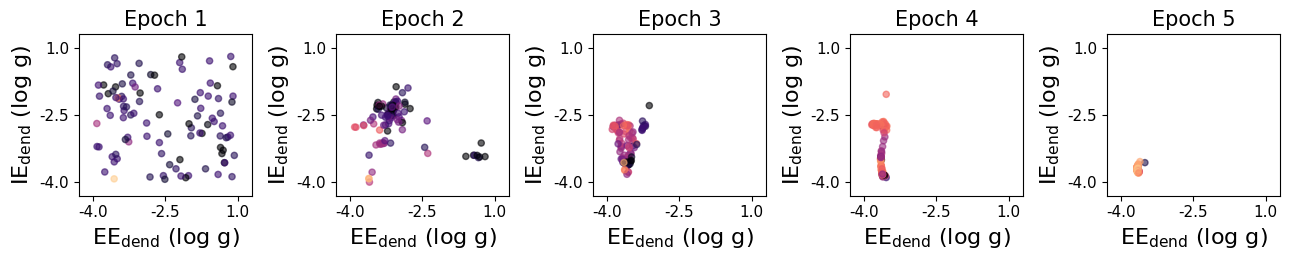

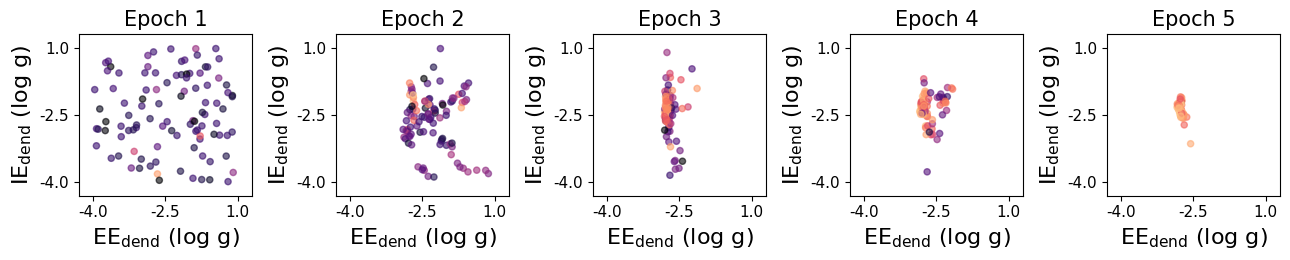

In [198]:
param_names = get_parameter_names()[0]


param1 = 'EE_dend_ampa_gS'
param2 = 'IE_dend_gaba_gS'

# param1 = 'EE_dend_ampa_gS'
# param2 = 'IE_dend_gaba_gS'

param1_idx = np.where(np.array(param_names) == param1)[0][0]
param2_idx = np.where(np.array(param_names) == param2)[0][0]

labelsize = 16
titlesize = 15
ticksize = 11
legendsize = 10.5

max_error = 5
min_error = 0

cmap = mpl.colormaps['magma']

# colors = ['C0', 'salmon'] # first color is black, last is red
# cmap = LinearSegmentedColormap.from_list(
#         "Custom", colors, N=100)

for name in ['cuedendnmda_Esomaampa_Edendampa', 'cuesomanmda_Esomaampa_Edendampa']:

    plt.figure(figsize=(13, 2.7))
    for plot_idx, flow_idx in enumerate(range(5)):
        plt.subplot(1, 5, plot_idx+1)
        theta = res_dict[name]['theta_list'][flow_idx]
        error = res_dict[name]['error_list'][flow_idx]

        error = (error - min_error) / (max_error - min_error)
        color = cmap(1-error)

        param1_theta = theta[:, param1_idx]
        param2_theta = theta[:, param2_idx]
        
        plt.scatter(param1_theta, param2_theta, c=color, s=20, alpha=0.6)
        plt.xlim(-0.1,1.1)
        plt.ylim(-0.1,1.1)

        plt.xticks([0, 0.5, 1], fontsize=ticksize, labels=[-4.0, -2.5, 1.0])
        plt.yticks([0, 0.5, 1], fontsize=ticksize, labels=[-4.0, -2.5, 1.0])

        plt.xlabel('$\\rm EE_{dend}$ (log g)', fontsize=labelsize)
        plt.ylabel('$\\rm IE_{dend}$ (log g)', fontsize=labelsize)
        plt.title(f'Epoch {flow_idx+1}', fontsize=titlesize)

    plt.tight_layout()


    